# Full Matrix Benchmark Analysis — 2026-07-07

Deep dive on `reports/20260707_full-matrix`: 6 enterprise architectures ×
10 `adi-*` tasks (+ `minimal` as a no-DB-access baseline), run in one
session against a single DB/ground-truth snapshot with the local
`qwen3.6-35b-a3b` model.

This notebook loads the raw `*_scored.json` reports directly (via
`generate_report_csvs.py`, so it always reflects the latest JSONs) and
explores the results in more detail than the summary CSVs: per-task
matrices, failure modes, score-quality breakdown (correctness vs.
groundedness vs. hallucination), elapsed-time distributions, and
head-to-head comparisons.

See also: [architecture-recommendation.canvas.tsx](../canvases/architecture-recommendation.canvas.tsx) for the narrative writeup this data supports.

In [4]:
import sys
import pathlib

import pandas as pd
import matplotlib.pyplot as plt

# Notebook lives in notebooks/ — project root is one level up
ROOT = pathlib.Path(__file__).parent.parent if "__file__" in dir() else pathlib.Path.cwd().parent
NOTEBOOKS = ROOT / "notebooks"
REPORTS_DIR = ROOT / "reports" / "20260707_full-matrix"

if str(NOTEBOOKS) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS))

from generate_report_csvs import ARCH_PRIORITY, load_results

plt.rcParams["figure.facecolor"] = "white"
pd.set_option("display.max_colwidth", 80)

raw = load_results(str(REPORTS_DIR))
df = pd.DataFrame(
    [
        {"task": task, "architecture": arch, **fields}
        for (task, arch), fields in raw.items()
    ]
)
df["score"] = df["score"].fillna(0.0)
df = df.rename(columns={"elapsed": "elapsed_seconds"})

TASK_ORDER = [
    "adi-top-modules", "adi-low-adoption", "adi-user-lookup", "adi-function-analysis",
    "adi-executive-users", "adi-module-ratings", "adi-monthly-trend",
    "adi-disengagement-risk", "adi-portfolio-depth", "adi-function-opportunity",
]
df["task"] = pd.Categorical(df["task"], categories=TASK_ORDER, ordered=True)
df["architecture"] = pd.Categorical(
    df["architecture"], categories=ARCH_PRIORITY + ["minimal"], ordered=True
)
df = df.sort_values(["task", "architecture"]).reset_index(drop=True)

print(f"{len(df)} rows loaded from {REPORTS_DIR}")
df.sort_values(['score'], inplace = True, ascending=False)
df.head()

70 rows loaded from /Users/srs/Projects/aily/agent_harness/reports/20260707_full-matrix


,task,architecture,ok,score,correctness,groundedness,hallucination_rate,elapsed_seconds,error
0,adi-top-modules,enterprise-react,True,1.0,1.0,1.0,0.0,4.067657,
7,adi-low-adoption,enterprise-react,True,1.0,1.0,1.0,0.0,3.585974,
24,adi-function-analysis,enterprise-mcp-codemode,True,1.0,1.0,1.0,0.0,27.143554,
12,adi-low-adoption,enterprise-sql-codemode,True,1.0,1.0,1.0,0.0,10.574823,
9,adi-low-adoption,enterprise-mcp-react,True,1.0,1.0,1.0,0.0,4.271872,


---
## 1 · Architecture leaderboard

`reliability_adjusted_score` counts a failed/timed-out run as `0` — a fast
wrong answer isn't "fast" in practice. `raw_score_when_ok` only averages
over runs that actually completed, so it shows the accuracy ceiling when
things work. `enterprise-react` excludes the `minimal` baseline (no DB
access, included only as a sanity-check floor).

In [5]:
enterprise_df = df[df["architecture"] != "minimal"].copy()
n_tasks = enterprise_df["task"].nunique()

def summarize(group: pd.DataFrame) -> pd.Series:
    ok = group[group["ok"]]
    return pd.Series({
        "reliability_adjusted_score": group["score"].mean(),
        "raw_score_when_ok": ok["score"].mean() if len(ok) else 0.0,
        "ok_rate": f"{len(ok)}/{n_tasks}",
        "avg_elapsed_s": ok["elapsed_seconds"].mean(),
        "median_elapsed_s": ok["elapsed_seconds"].median(),
        "tasks_won": None,  # filled in below
    })

summary = enterprise_df.groupby("architecture", observed=True).apply(
    summarize, include_groups=False
)

# tasks won: per task, the architecture with the highest score (ties broken
# by ARCH_PRIORITY, matching the canvas convention)
winners = (
    enterprise_df.sort_values("architecture", key=lambda s: s.map({a: i for i, a in enumerate(ARCH_PRIORITY)}))
    .groupby("task", observed=True)
    .apply(lambda g: g.loc[g["score"].idxmax(), "architecture"], include_groups=False)
)
summary["tasks_won"] = winners.value_counts().reindex(summary.index, fill_value=0)

summary = summary.sort_values("reliability_adjusted_score", ascending=False)
summary.round(3)

,reliability_adjusted_score,raw_score_when_ok,ok_rate,avg_elapsed_s,median_elapsed_s,tasks_won
architecture,,,,,,
enterprise-react,0.760,0.844,9/10,34.050,29.008,5
enterprise-sql-codemode,0.633,0.633,10/10,35.831,24.427,0
enterprise-mcp-react,0.624,0.780,8/10,36.399,22.311,3
enterprise-sql-react,0.559,0.698,8/10,28.151,28.927,0
enterprise-mcp-codemode,0.513,0.734,7/10,36.201,27.144,1
enterprise-codemode,0.467,0.667,7/10,40.231,32.695,1


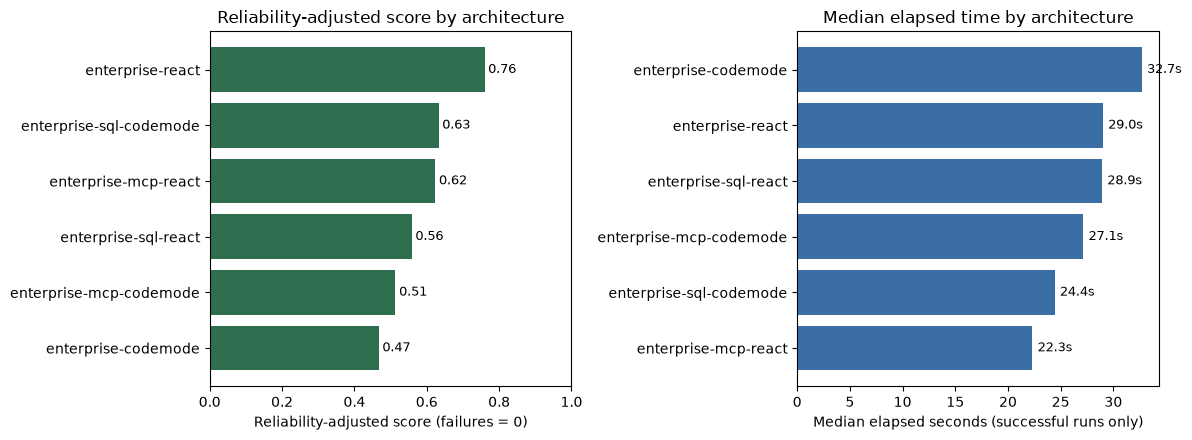

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ordered = summary.index.tolist()

axes[0].barh(ordered, summary["reliability_adjusted_score"], color="#2f6f4f")
axes[0].set_xlabel("Reliability-adjusted score (failures = 0)")
axes[0].set_title("Reliability-adjusted score by architecture")
axes[0].set_xlim(0, 1)
axes[0].invert_yaxis()
for y, v in enumerate(summary["reliability_adjusted_score"]):
    axes[0].text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=9)

med_sorted = summary["median_elapsed_s"].sort_values()
axes[1].barh(med_sorted.index, med_sorted.values, color="#3b6ea5")
axes[1].set_xlabel("Median elapsed seconds (successful runs only)")
axes[1].set_title("Median elapsed time by architecture")
for y, v in enumerate(med_sorted.values):
    axes[1].text(v + 0.5, y, f"{v:.1f}s", va="center", fontsize=9)

plt.tight_layout()
plt.show()

---
## 2 · Full task × architecture matrix

Score heatmap (failures shown as 0 / red) and a matching table so exact
elapsed times and error messages are still visible.

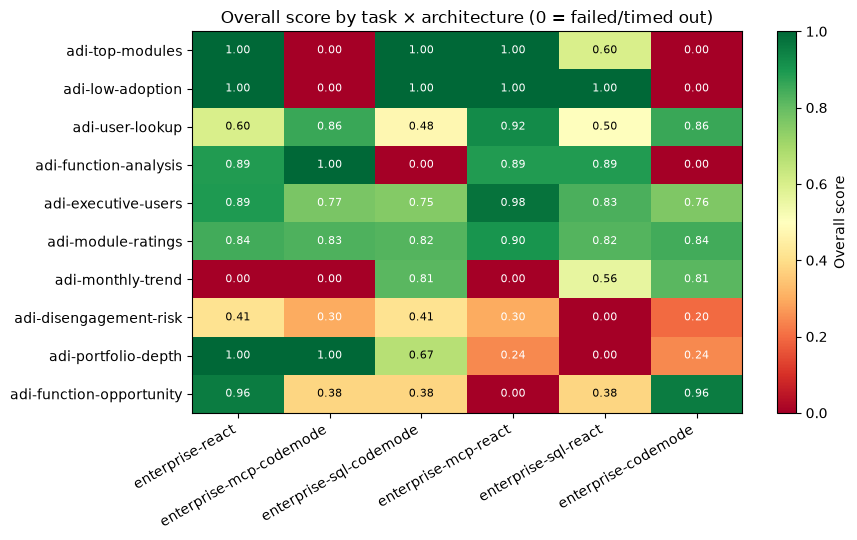

In [9]:
score_matrix = enterprise_df.pivot(index="task", columns="architecture", values="score")

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(score_matrix.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(score_matrix.columns)))
ax.set_xticklabels(score_matrix.columns, rotation=30, ha="right")
ax.set_yticks(range(len(score_matrix.index)))
ax.set_yticklabels(score_matrix.index)
ax.set_title("Overall score by task × architecture (0 = failed/timed out)")
for i in range(score_matrix.shape[0]):
    for j in range(score_matrix.shape[1]):
        v = score_matrix.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v < 0.35 or v > 0.75 else "black")
fig.colorbar(im, ax=ax, label="Overall score")
plt.tight_layout()
plt.show()

In [5]:
def fmt_cell(row: pd.Series) -> str:
    if not row["ok"]:
        return f"FAIL · {row['elapsed_seconds']:.0f}s"
    return f"{row['score']:.2f} · {row['elapsed_seconds']:.0f}s"

display_matrix = enterprise_df.copy()
display_matrix["cell"] = display_matrix.apply(fmt_cell, axis=1)
display_matrix.pivot(index="task", columns="architecture", values="cell")

architecture,enterprise-react,enterprise-codemode,enterprise-mcp-react,enterprise-mcp-codemode,enterprise-sql-react,enterprise-sql-codemode
task,,,,,,
adi-top-modules,1.00 · 4s,FAIL · 3s,1.00 · 5s,FAIL · 3s,0.60 · 16s,1.00 · 20s
adi-low-adoption,1.00 · 4s,FAIL · 3s,1.00 · 4s,FAIL · 2s,1.00 · 7s,1.00 · 11s
adi-user-lookup,0.60 · 10s,0.86 · 11s,0.92 · 7s,0.86 · 9s,0.50 · 26s,0.48 · 18s
adi-function-analysis,0.89 · 32s,FAIL · 180s,0.89 · 22s,1.00 · 27s,0.89 · 32s,0.00 · 29s
adi-executive-users,0.89 · 84s,0.76 · 100s,0.98 · 119s,0.77 · 77s,0.83 · 42s,0.75 · 52s
adi-module-ratings,0.84 · 27s,0.84 · 33s,0.90 · 77s,0.83 · 22s,0.82 · 19s,0.82 · 22s
adi-monthly-trend,FAIL · 33s,0.81 · 22s,FAIL · 180s,FAIL · 5s,0.56 · 37s,0.81 · 21s
adi-disengagement-risk,0.41 · 29s,0.20 · 36s,0.30 · 33s,0.30 · 47s,FAIL · 13s,0.41 · 75s
adi-portfolio-depth,1.00 · 34s,0.24 · 14s,0.24 · 22s,1.00 · 15s,FAIL · 13s,0.67 · 85s


---
## 3 · Where each architecture fails

Every `ok == False` run, its error, and how long it burned before giving up.
Grouped by failure type to spot patterns (e.g. CodeMode architectures
repeatedly trying to call wrapped tools directly by name).

In [6]:
def categorize_error(err: str) -> str:
    if not err:
        return "n/a"
    if "TIMEOUT" in err:
        return "timeout (180s cap)"
    if "exceeded max retries" in err or "retries exceeded" in err:
        return "unknown/wrapped tool name, retries exceeded"
    if "UsageLimitExceeded" in err:
        return "usage limit (>50 tool calls)"
    if "SQLError" in err:
        return "SQL syntax error"
    return "other"

failures = enterprise_df[~enterprise_df["ok"]].copy()
failures["failure_type"] = failures["error"].map(categorize_error)

print(f"{len(failures)} / {len(enterprise_df)} enterprise-architecture runs failed\n")
display(
    failures.groupby(["failure_type", "architecture"], observed=True)
    .size()
    .unstack(fill_value=0)
)

11 / 60 enterprise-architecture runs failed



architecture,enterprise-react,enterprise-codemode,enterprise-mcp-react,enterprise-mcp-codemode,enterprise-sql-react
failure_type,,,,,
SQL syntax error,0,0,0,0,2
timeout (180s cap),0,1,2,0,0
"unknown/wrapped tool name, retries exceeded",0,2,0,3,0
usage limit (>50 tool calls),1,0,0,0,0


In [7]:
(
    failures[["task", "architecture", "failure_type", "elapsed_seconds", "error"]]
    .sort_values(["architecture", "task"])
    .reset_index(drop=True)
)

,task,architecture,failure_type,elapsed_seconds,error
0,adi-monthly-trend,enterprise-react,usage limit (>50 tool calls),32.589510,UsageLimitExceeded: The next request would exceed the request_limit of 50
1,adi-top-modules,enterprise-codemode,"unknown/wrapped tool name, retries exceeded",3.191216,UnexpectedModelBehavior: Tool 'get_top_selling_products' exceeded max retrie...
2,adi-low-adoption,enterprise-codemode,"unknown/wrapped tool name, retries exceeded",3.472613,UnexpectedModelBehavior: Tool 'get_low_stock_products' exceeded max retries ...
3,adi-function-analysis,enterprise-codemode,timeout (180s cap),180.000000,TIMEOUT: exceeded 180s wall clock
4,adi-monthly-trend,enterprise-mcp-react,timeout (180s cap),180.000000,TIMEOUT: exceeded 180s wall clock
5,adi-function-opportunity,enterprise-mcp-react,timeout (180s cap),180.000000,TIMEOUT: exceeded 180s wall clock
6,adi-top-modules,enterprise-mcp-codemode,"unknown/wrapped tool name, retries exceeded",2.979151,UnexpectedModelBehavior: Tool 'tool_get_top_selling_products' exceeded max r...
7,adi-low-adoption,enterprise-mcp-codemode,"unknown/wrapped tool name, retries exceeded",2.445893,UnexpectedModelBehavior: Tool 'tool_get_low_stock_products' exceeded max ret...
8,adi-monthly-trend,enterprise-mcp-codemode,"unknown/wrapped tool name, retries exceeded",4.558836,UnexpectedModelBehavior: Tool 'tool_list_tables' exceeded max retries count ...
9,adi-disengagement-risk,enterprise-sql-react,SQL syntax error,12.726999,"SQLError: near ""FROM"": syntax error"


---
## 4 · Score quality breakdown: correctness vs. groundedness vs. hallucination

`overall_score` is the harmonic mean of `correctness` (did it recall the
right facts) and `groundedness` (are the numbers it claimed actually
verifiable). `hallucination_rate` is `1 - groundedness`. Averaged only over
runs that completed (`ok == True`) so failures don't zero these out.

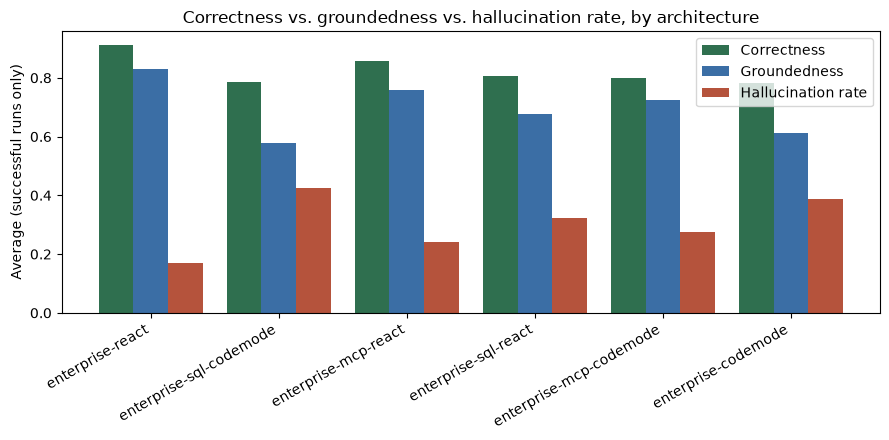

,correctness,groundedness,hallucination_rate
architecture,,,
enterprise-react,0.913,0.832,0.168
enterprise-sql-codemode,0.786,0.577,0.423
enterprise-mcp-react,0.858,0.759,0.241
enterprise-sql-react,0.808,0.677,0.323
enterprise-mcp-codemode,0.800,0.724,0.276
enterprise-codemode,0.782,0.613,0.387


In [8]:
ok_df = enterprise_df[enterprise_df["ok"]]
quality = ok_df.groupby("architecture", observed=True)[
    ["correctness", "groundedness", "hallucination_rate"]
].mean().reindex(ordered)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(quality))
width = 0.27
ax.bar([i - width for i in x], quality["correctness"], width, label="Correctness", color="#2f6f4f")
ax.bar(x, quality["groundedness"], width, label="Groundedness", color="#3b6ea5")
ax.bar([i + width for i in x], quality["hallucination_rate"], width, label="Hallucination rate", color="#b5533c")
ax.set_xticks(list(x))
ax.set_xticklabels(quality.index, rotation=30, ha="right")
ax.set_ylabel("Average (successful runs only)")
ax.set_title("Correctness vs. groundedness vs. hallucination rate, by architecture")
ax.legend()
plt.tight_layout()
plt.show()

quality.round(3)

---
## 5 · Elapsed time distribution

Box plot of per-run elapsed seconds for successful runs, showing spread
(not just the median reported in the leaderboard above) — some
architectures are consistently mid-pack but have a much longer tail on
harder tasks.

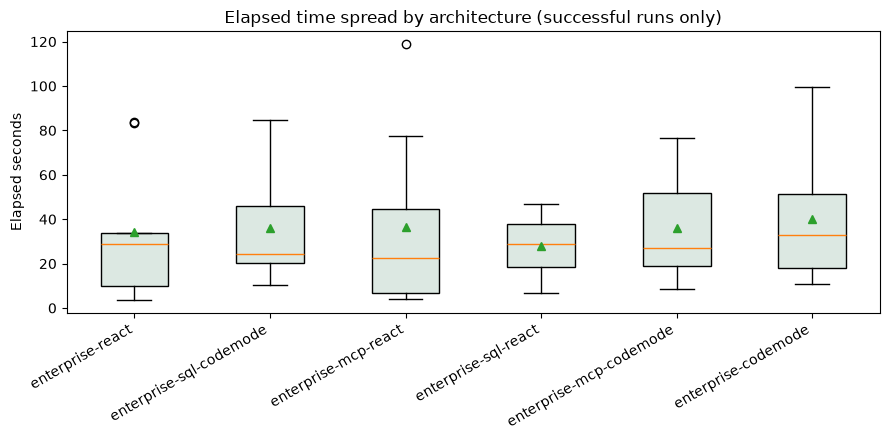

In [9]:
box_data = [ok_df[ok_df["architecture"] == a]["elapsed_seconds"].values for a in ordered]

fig, ax = plt.subplots(figsize=(9, 4.5))
bp = ax.boxplot(box_data, tick_labels=ordered, patch_artist=True, showmeans=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#dce8e2")
ax.set_ylabel("Elapsed seconds")
ax.set_title("Elapsed time spread by architecture (successful runs only)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
## 6 · Does taking longer correlate with a better score?

Scatter of elapsed seconds vs. score for successful runs, colored by
architecture. If there's no visible trend, speed differences are mostly
architectural overhead rather than "thinking longer = more correct."

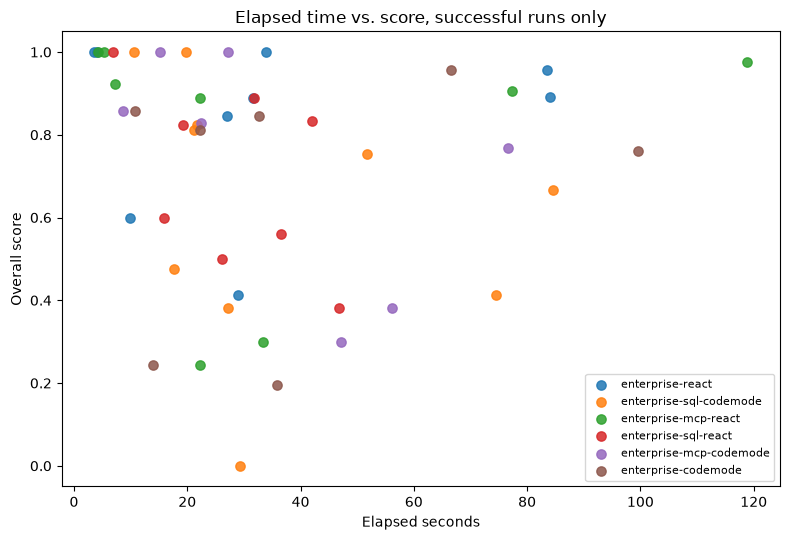

Pearson correlation (elapsed vs. score), successful runs only: -0.049


In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
cmap = plt.get_cmap("tab10")
for i, arch in enumerate(ordered):
    sub = ok_df[ok_df["architecture"] == arch]
    ax.scatter(sub["elapsed_seconds"], sub["score"], label=arch, color=cmap(i), s=45, alpha=0.85)
ax.set_xlabel("Elapsed seconds")
ax.set_ylabel("Overall score")
ax.set_title("Elapsed time vs. score, successful runs only")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

corr = ok_df["elapsed_seconds"].corr(ok_df["score"])
print(f"Pearson correlation (elapsed vs. score), successful runs only: {corr:.3f}")

---
## 7 · Per-task winner and runner-up

For each task: the best architecture, its score, and the gap to the
second-best — a small gap means the task doesn't strongly discriminate
between architectures; a large gap means architecture choice matters a lot
for that specific task.

In [11]:
priority_rank = {a: i for i, a in enumerate(ARCH_PRIORITY)}

def top_two(group: pd.DataFrame) -> pd.Series:
    g = group.sort_values(
        ["score", "architecture"],
        ascending=[False, True],
        key=lambda s: s.map(priority_rank) if s.name == "architecture" else s,
    )
    best, runner_up = g.iloc[0], g.iloc[1]
    return pd.Series({
        "winner": best["architecture"],
        "winner_score": best["score"],
        "runner_up": runner_up["architecture"],
        "runner_up_score": runner_up["score"],
        "gap": best["score"] - runner_up["score"],
    })

per_task = enterprise_df.groupby("task", observed=True).apply(top_two, include_groups=False)
per_task.round(3).sort_values("gap")

,winner,winner_score,runner_up,runner_up_score,gap
task,,,,,
adi-top-modules,enterprise-react,1.000,enterprise-mcp-react,1.000,0.000
adi-low-adoption,enterprise-react,1.000,enterprise-mcp-react,1.000,0.000
adi-monthly-trend,enterprise-codemode,0.812,enterprise-sql-codemode,0.812,0.000
adi-disengagement-risk,enterprise-react,0.414,enterprise-sql-codemode,0.414,0.000
adi-portfolio-depth,enterprise-react,1.000,enterprise-mcp-codemode,1.000,0.000
adi-function-opportunity,enterprise-react,0.956,enterprise-codemode,0.956,0.000
adi-module-ratings,enterprise-mcp-react,0.905,enterprise-react,0.845,0.060
adi-user-lookup,enterprise-mcp-react,0.923,enterprise-codemode,0.857,0.066
adi-executive-users,enterprise-mcp-react,0.976,enterprise-react,0.892,0.084


---
## 8 · Head-to-head: the two-architecture shortlist

`enterprise-react` (highest reliability-adjusted score) vs.
`enterprise-sql-codemode` (only 10/10 architecture, zero outright
failures) — per task, which one is ahead and by how much.

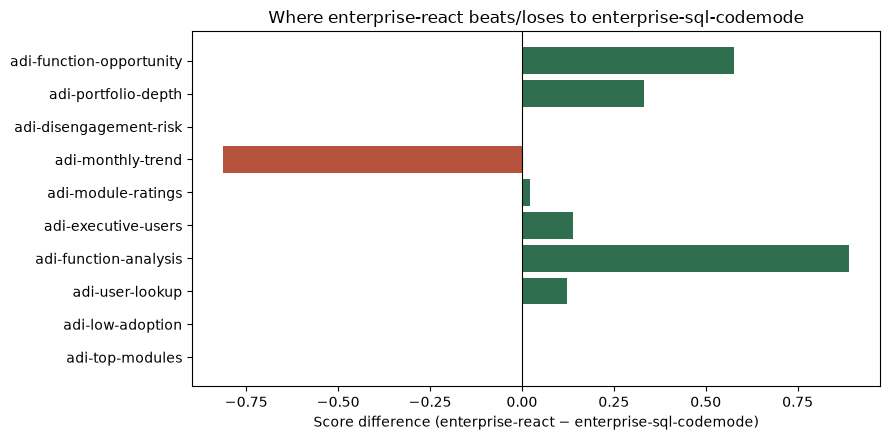

architecture,enterprise-react,enterprise-sql-codemode,react_minus_sql_codemode
task,,,
adi-top-modules,1.000,1.000,0.000
adi-low-adoption,1.000,1.000,0.000
adi-user-lookup,0.600,0.476,0.124
adi-function-analysis,0.889,0.000,0.889
adi-executive-users,0.892,0.753,0.139
adi-module-ratings,0.845,0.823,0.022
adi-monthly-trend,0.000,0.812,-0.812
adi-disengagement-risk,0.414,0.414,0.000
adi-portfolio-depth,1.000,0.667,0.333


In [12]:
shortlist = ["enterprise-react", "enterprise-sql-codemode"]
head_to_head = (
    enterprise_df[enterprise_df["architecture"].isin(shortlist)]
    .pivot(index="task", columns="architecture", values="score")
)
head_to_head["react_minus_sql_codemode"] = (
    head_to_head["enterprise-react"] - head_to_head["enterprise-sql-codemode"]
)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2f6f4f" if v >= 0 else "#b5533c" for v in head_to_head["react_minus_sql_codemode"]]
ax.barh(head_to_head.index.astype(str), head_to_head["react_minus_sql_codemode"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Score difference (enterprise-react − enterprise-sql-codemode)")
ax.set_title("Where enterprise-react beats/loses to enterprise-sql-codemode")
plt.tight_layout()
plt.show()

head_to_head.round(3)

---
## 9 · Sanity check: the `minimal` (no-DB-access) baseline

`minimal` has no tools to query the enterprise DB, so it should score near
zero on every task that requires real data — confirming the scorer isn't
handing out credit for plausible-sounding hallucinations.

In [13]:
minimal_df = df[df["architecture"] == "minimal"][["task", "score", "hallucination_rate"]].set_index("task")
print(f"minimal baseline average score: {minimal_df['score'].mean():.3f}")
print(f"minimal baseline average hallucination rate: {minimal_df['hallucination_rate'].mean():.3f}")
minimal_df.round(3)

minimal baseline average score: 0.062
minimal baseline average hallucination rate: 0.790


,score,hallucination_rate
task,,
adi-top-modules,0.000,1.000
adi-low-adoption,0.125,0.750
adi-user-lookup,0.105,0.857
adi-function-analysis,0.000,1.000
adi-executive-users,0.000,0.000
adi-module-ratings,0.133,0.667
adi-monthly-trend,0.000,1.000
adi-disengagement-risk,0.030,0.963
adi-portfolio-depth,0.000,1.000
